[ Info: Saved animation to /home/cofeina/Programming/notebook-ideas/julia/tmp.gif


Plots.AnimatedGif("/home/cofeina/Programming/notebook-ideas/julia/tmp.gif")
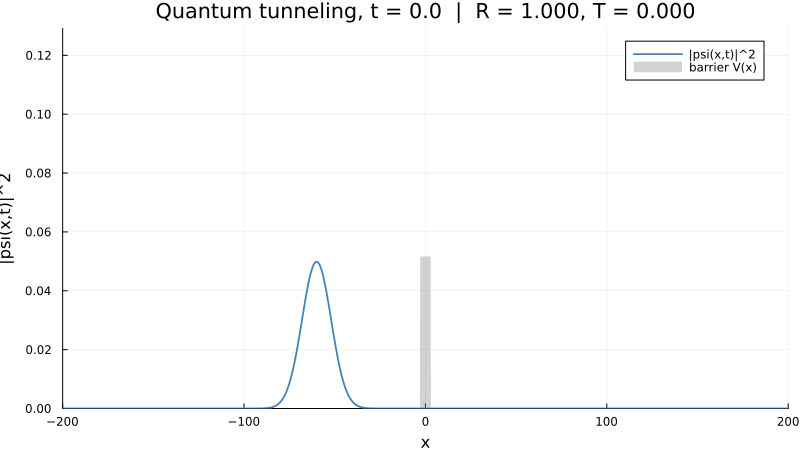

Final: R = 0.1487, T = 0.8513, R+T = 1.0000


In [10]:
using Plots
using FFTW
using Printf

gr()

N = 2048
L = 400.0
x = range(-L/2, L/2, length=N)
dx = x[2] - x[1]

# momentum-space grid matching FFT convention
k = 2π * FFTW.fftfreq(N, 1/dx)
x0 = -60.0         # initial position, well to the left of the barrier
sigma = 8.0        # initial width
k0 = 1.2           # initial momentum (sets kinetic energy E = k0^2 / 2)

psi0 = (1.0 / (2π * sigma^2))^0.25 .* exp.(
    -((x .- x0).^2) ./ (4 * sigma^2) .+ 1im * k0 .* x
)
psi0 ./= sqrt(sum(abs2.(psi0)) * dx)  # normalize

E = 0.5 * k0^2      # mean kinetic energy of the packet

V0 = 0.7 * E        # barrier height, relative to packet energy
                    # V0 < E -> classically mostly transmits, but QM still reflects some
width = 6.0         # barrier width
V = [abs(xi) < width/2 ? V0 : 0.0 for xi in x]

# ----------------------------- time propagation -----------------------------
dt = 0.05
n_steps = 3200
snap_every = 20

half_pot = exp.(-1im .* V .* dt / 2)
kin = exp.(-1im .* (k.^2) .* dt / 2)

psi = copy(psi0)
frames = Vector{Vector{Float64}}()
R_hist = Float64[]
T_hist = Float64[]
t_hist = Float64[]

# regions used to bookkeep reflected/transmitted probability
left_mask = x .< (-width/2 - 2*sigma)
right_mask = x .> (width/2 + 2*sigma)

for step in 0:n_steps
    if step % snap_every == 0
        prob = abs2.(psi)
        push!(frames, prob)
        push!(R_hist, sum(prob[left_mask]) * dx)
        push!(T_hist, sum(prob[right_mask]) * dx)
        push!(t_hist, step * dt)
    end

    # Strang split-step: half potential step, full kinetic step (via FFT), half potential step
    psi .= half_pot .* psi
    psi .= ifft(kin .* fft(psi))
    psi .= half_pot .* psi
end

ymax = maximum(maximum.(frames)) * 1.15

# ----------------------------- build the animation -----------------------------
anim = @animate for i in 1:length(frames)
    plot(x, frames[i],
        xlim = (-L/2, L/2), ylim = (0, ymax),
        xlabel = "x", ylabel = "|psi(x,t)|^2",
        label = "|psi(x,t)|^2", lw = 1.8, color = :steelblue,
        title = @sprintf("Quantum tunneling, t = %.1f  |  R = %.3f, T = %.3f",
                          t_hist[i], R_hist[i], T_hist[i]),
        size = (800, 450))

    plot!(x, V ./ V0 .* ymax .* 0.4, fillrange = 0, alpha = 0.35,
        color = :grey, label = "barrier V(x)", linewidth = 0)
end

# ----------------------------- display inline in the notebook -----------------------------
# explicit display() so it shows regardless of what comes after in the cell
display(gif(anim, fps = 25))

@printf("Final: R = %.4f, T = %.4f, R+T = %.4f\n", R_hist[end], T_hist[end], R_hist[end] + T_hist[end])